#importing libraries that i may need.

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import numpy as np

#importing and checking to see if my two datasets are imported correctly

In [42]:
try:
    df1 = pd.read_csv('../Data/cleaned_heart_failure.csv')
    df2 = pd.read_csv('../Data/cleaned_df_heart_disease.csv')
    print('Files loaded successfully')
except FileNotFoundError:
    print("Error: Make sure 'heart.csv' and 'heart_disease.csv' are in this exact folder.")

Files loaded successfully


genetics chart
-Age- Patients age in years(Maps to age/Age).
-Gender- Biological sex(Maps to sex [0=Female, 1=Male] or Gender).
-Family Heart Disease- Hereditary history variables(Maps to family_history/Family History).

Habits Chart
-Smoking Habits- Binary tobacco consumption (Maps to smoke/Smoking).
-Exercise Patterns- Activity frequencies(Maps to exang/Exercise Habits).
-Alcohol Consumption- intake metric tracking (Maps to alco/ Alcohol Consumption).
-Diet/Sugar Consumption- Nutritional risk indices (Maps to Sugar Consumption)

Outcome Chart
-Blood Pressure-Exact continuous systolic value (Maps to trestvps/RestingBP).
-High Blood Pressure- Clinical diagnostic boolean (Maps to high_blood_pressure/Hypertension).
-Cholestrol Level-Total serum cholestrol mg/dl (Maps to chol / Cholestrol Level).
-High LDL Cholestrol- Elevated density lipoprotein flag (Maps to ldl/High LDL Cholestrol).
-Low HDL Cholestrol- Low protective cholesterol flag(Maps to hdl/low hdl Cholesterol).
-Heart Disease Status- Finalclinical target presentation (Maps to target/HeartDisease).

#Standarize column naming systems for simple alignment

In [43]:
df1.rename(columns={
    'age': 'Genetics_Age',
    'sex': 'Genetics_Gender',
    'trestbps': 'Outcomes_Blood_Pressure',
    'chol': 'Outcomes_Cholesterol',
    'target': 'Outcomes_Heart_Disease'
}, inplace=
True)

df2.rename(columns={
    'Age': 'Genetics_Age',
    'Gender': 'Genetics_Gender',
    'Smoking': 'Habits_Smoking', 
    'Exercise Habits': 'Habits_Exercise', 
    'Alcohol Consumption': 'Habits_Alcohol', 
    'Sugar Consumption': 'Habits_Diet',
    'Blood Pressure': 'Outcomes_Blood_Pressure', 
    'High Blood Pressure': 'Outcomes_High_BP', 
    'Cholestrol Level': 'Outcomes_Cholestrol', 
    'High LDL Cholesterol': 'Outcomes_High_LDL', 
    'Low HDL Cholesterol': 'Outcomes_Low_HDL',
    'Heart Disease': 'Outcomes_Heart_Disease'
}, inplace=True)


#Define final ordered chart format structure

In [44]:
final_columns = [ 
    'Genetics_Age', 'Genetics_Gender', 
    'Habits_Smoking', 'Habits_Exercise', 'Habits_Alcohol', 'Habits_Diet', 
    'Outcomes_Blood_Pressure', 'Outcomes_High_BP', 'Outcomes_Cholesterol',
    'Outcomes_High_LDL', 'Outcomes_Low_HDL', 'Outcomes_Heart_Disease'
]

#trying out a mermaid erd schema

```mermaid

erDiagram
    PATIENTS {
        int patient_id PK 
    }
    GENETICS{
        int genetics_id PK 
        int patient_id FK 
        int Genetics_Age
        string Genetics_Gender
    }

    HABITS {
        int habit_id PK 
        int patient_id FK
        string Habits_Smoking
        string Habits_Exercise
        string Habits_Alcohol
        string Habits_Diet
    }

    OUTCOMES {
        int outcome_id PK 
        int patient_id FK 
        int Outcomes_Blood_Pressure
        boolean Outcomes_High_BP
        int Outcomes_Cholesterol
        boolean Outcomes_High_LDL
        boolean Outcomes_Low_HDL
        boolean Outcomes_Heart_Disease
    }
    
    PATIENTS ||--|| GENETICS : "has"
    PATIENTS ||--o{ HABITS : "practices"
    PATIENTS ||--o{ OUTCOMES : "records"

```

#Merge data fields smoothly and preserve non-intersecting spaces with blanks

In [45]:
combined_df = pd.concat([df1,df2],axis=0, ignore_index=True)
combined_df = combined_df.reindex(columns=final_columns)

#Export structural results to disk

In [46]:
combined_df.to_csv("combined_heart_charts.csv", index=False)
print("Success! Your organized file 'combined_heart_charts.csv' has been generated.")

Success! Your organized file 'combined_heart_charts.csv' has been generated.


#load you newly combined dataset

In [47]:
df = pd.read_csv("combined_heart_charts.csv")

Force all Column names to lowercase to prevent causing errors

In [48]:
df.columns = df.columns.str.lower()

#Initialize an in memory SQLite connection


In [49]:
conn = sqlite3.connect(':memory:')

#write the data to a sql table named 'heart_data'

In [50]:
df.to_sql('heart_data', conn, index=False, if_exists='replace')

10918

Question 1: How do habits like smoking impact metrics like blood pressure and ultimate heart disease rates?

This query groups the dataset by smoking habits to directly compare average biological metrics and calculated outcomes between groups.


In [51]:
query_1 = """
SELECT
    Habits_Smoking,
	COUNT(*) AS Total_Patients,
	ROUND(AVG(Genetics_Age), 1) As Avg_Age,
	ROUND(AVG(Outcomes_Blood_Pressure), 1) AS Avg_Blood_Pressure,
	ROUND(SUM(CASE WHEN Outcomes_Heart_Disease = 'Yes' THEN 1 Else 0 END) * 100.0/COUNT (*), 2) AS Heart_Disease_Rate_Pct
FROM heart_data
GROUP BY Habits_Smoking;
"""
#Execute and view results
result_1 = pd.read_sql_query(query_1, conn)
print(result_1)

  habits_smoking  Total_Patients  Avg_Age Avg_Blood_Pressure  \
0            NaN             918      NaN               None   
1             No            4852     49.3               None   
2        Unknown              25     46.2               None   
3            Yes            5123     49.3               None   

   Heart_Disease_Rate_Pct  
0                     0.0  
1                     0.0  
2                     0.0  
3                     0.0  


#Visualization

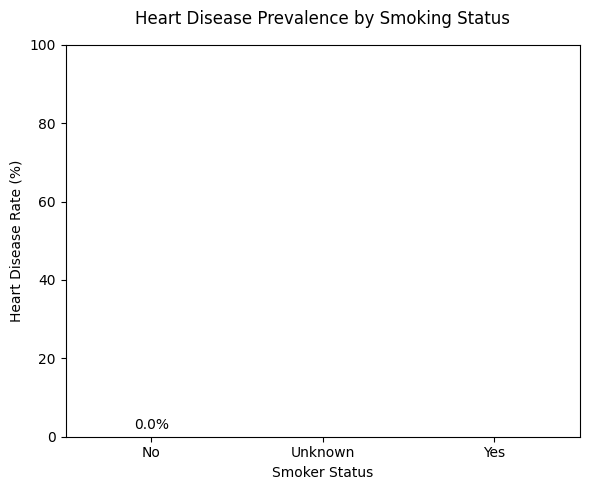

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [52]:
plt.figure(figsize=(6,5))
barplot_1 = sns.barplot(
    data = result_1,
    x='habits_smoking',
    y='Heart_Disease_Rate_Pct',
    palette='Reds_r',
    hue='habits_smoking',
    legend=False,
)
plt.title("Heart Disease Prevalence by Smoking Status", pad=15)
plt.xlabel("Smoker Status")
plt.ylabel("Heart Disease Rate (%)")
plt.ylim(0, 100)

for p in barplot_1.patches: 
    barplot_1.annotate(
        f"{p.get_height():.1f}%",
        (p.get_x() + p.get_width() / 2.0, p.get_height() + 2),
        ha="center",
    )
    plt.tight_layout()
    plt.show()

Question 2: Which age groups (divided by decade) have the highest prevalence of overlapping risk factors like combined high blood pressure and high LDL cholesterol?

This question uses integer math to bucket patients into age groups(e.g., 40s, 50s, 60s) to discover exactly when dangerous clinical outcomes begin compounding.


In [53]:
query_2 = """
SELECT
	(Genetics_Age / 10) * 10 AS Age_Decade,
	COUNT(*) AS Total_Patients,
	SUM(CASE WHEN Outcomes_High_BP = 'Yes' AND Outcomes_High_LDL = 'Yes' THEN 1 ELSE 0 END) AS Combined_High_BP_and_LDL_Count,
	SUM(CASE WHEN Outcomes_Heart_Disease = 'Yes' THEN 1 ELSE 0 END) AS Heart_Disease_Count
FROM heart_data
GROUP BY Age_Decade
ORDER BY Age_Decade ASC;
"""
#Execute and view results
result_2 = pd.read_sql_query(query_2, conn)
print(result_2)

    Age_Decade  Total_Patients  Combined_High_BP_and_LDL_Count  \
0          NaN             947                               0   
1         18.0             149                               0   
2         19.0             155                               0   
3         20.0             154                               0   
4         21.0             162                               0   
..         ...             ...                             ...   
59        76.0             176                               0   
60        77.0             169                               0   
61        78.0             159                               0   
62        79.0             168                               0   
63        80.0             160                               0   

    Heart_Disease_Count  
0                     0  
1                     0  
2                     0  
3                     0  
4                     0  
..                  ...  
59                    0  

#Visualization

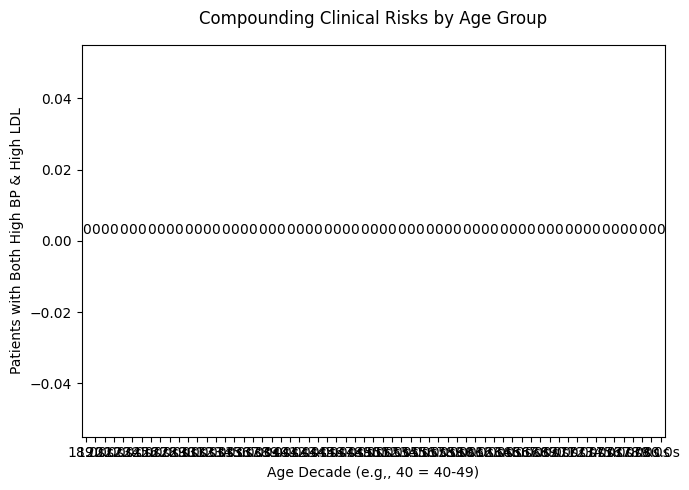

In [54]:
result_2["Age_Group_Label"] = result_2["Age_Decade"].astype(str) + "s"
plt.figure(figsize=(7,5))
barplot_2 = sns.barplot(
    data=result_2,
    x="Age_Group_Label",
    y="Combined_High_BP_and_LDL_Count",
    palette="Purples",
    hue="Age_Group_Label",
    legend=False,
)
plt.title("Compounding Clinical Risks by Age Group", pad=15)
plt.xlabel("Age Decade (e.g,, 40 = 40-49)")
plt.ylabel("Patients with Both High BP & High LDL")
for p in barplot_2.patches:
    height = p.get_height()
    barplot_2.annotate(
        f"{int(height)}",
        (p.get_x() + p.get_width() / 2.0, height),
        ha="center",
        va="bottom",
        xytext=(0, 3),
        textcoords="offset points",
    )
    
plt.tight_layout()
plt.show()

Question 3: How do genetic factors like gender baseline rates map against negative health indicators like high total choleserol or low HDL?

This focuses on demographic baselines to find out whether biological gender plays a stark historical role in high/low lipid configurations and positive disease outcomes.


In [55]:
query_3 = """
SELECT
	Genetics_Gender,
	COUNT(*) AS Total_Sample,
	ROUND(AVG(Outcomes_Cholesterol), 1) AS Avg_Total_Cholesterol,
	SUM(CASE WHEN Outcomes_Low_HDL = 'Yes' THEN 1 ELSE 0 END) AS Patients_With_Low_HDL,
	SUM(CASE WHEN Outcomes_Heart_Disease = 'Yes' THEN 1 ELSE 0 END) AS Total_Heart_Disease_Cases
FROM heart_data
GROUP BY Genetics_Gender;
"""
result_3 = pd.read_sql_query(query_3, conn)
print(result_3)

  genetics_gender  Total_Sample Avg_Total_Cholesterol  Patients_With_Low_HDL  \
0             NaN           918                  None                      0   
1          Female          4978                  None                   2473   
2            Male          5003                  None                   2516   
3         Unknown            19                  None                     11   

   Total_Heart_Disease_Cases  
0                          0  
1                          0  
2                          0  
3                          0  


#incase it was stored as a string instead of a numeric value

In [56]:
result_3["Avg_Total_Cholesterol"] = pd.to_numeric(result_3["Avg_Total_Cholesterol"], errors="coerce")


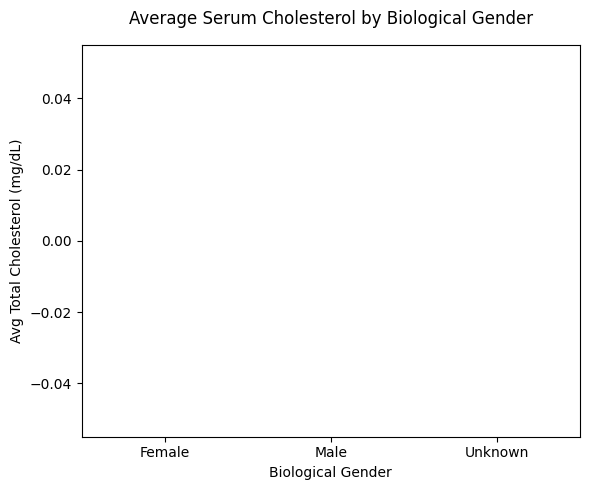

In [57]:
plt.figure(figsize=(6, 5))
barplot_3 = sns.barplot(
    data = result_3,
    x="genetics_gender",
    y="Avg_Total_Cholesterol",
    palette="Blues_d",
    hue="genetics_gender",
    legend=False,
)
plt.title("Average Serum Cholesterol by Biological Gender", pad=15)
plt.xlabel("Biological Gender")
plt.ylabel("Avg Total Cholesterol (mg/dL)")

for p in barplot_3.patches:
    height = p.get_height()
    if not pd.isna(height):
        barplot_3.annotate(
            f"{height:.1f}",
            (p.get_x() + p.get_width() / 2.0, height + 5),
    ha="center",
)
plt.tight_layout()
plt.show()